# Advanced Exploratory Data Analysis: Tatoeba Language Detection

This notebook performs a deep linguistic and statistical audit of the Tatoeba dataset. The goal is to provide high-level insights for an RNN-based language detector, focusing on character-level features, language separability, and lexical complexity.

### Objectives:
1. **Character N-gram Fingerprinting**: Identifying unique language features.
2. **Language Similarity Heatmap**: Analyzing potential classification confusion.
3. **Dimensionality Reduction (t-SNE)**: Visualizing language clusters in 2D space.
4. **Information Theory**: Measuring language entropy and lexical richness.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
from sklearn.preprocessing import normalize
import scipy.stats as stats

# Set high-resolution plotting aesthetics
# set a constant color palette
sns.set_theme(style="whitegrid", palette="Blues") #, palette="viridis")
plt.rcParams['figure.figsize'] = (20, 14)
plt.rcParams['font.size'] = 12

print("Environment initialized.")

Environment initialized.


## 1. Data Loading

We load the training set. We use character-level analysis to maintain the granularity required for the upcoming RNN tasks.

In [2]:
data_dir = "tatoeba"
train_file = os.path.join(data_dir, "sentences.top10langs.train.tsv")
dev_file = os.path.join(data_dir, "sentences.top10langs.dev.tsv")

# Read the files
train_df = pd.read_csv(train_file, sep='\t', header=None, names=['lang', 'text'])
dev_df = pd.read_csv(dev_file, sep='\t', header=None, names=['lang', 'text'])

print(f"Train set: {len(train_df)} rows")
print(f"Dev set: {len(dev_df)} rows")

train_df.head()

Train set: 99863 rows
Dev set: 10000 rows


,lang,text
0,spa,"Te di mi corazón para que lo ames, ¡no para us..."
1,spa,Contamos con tu ayuda.
2,spa,Tú eres superficial y materialista.
3,spa,Los límites son para los demás.
4,spa,Todos ellos esperaron ansiosamente las vacacio...


## 2. Statistical Analysis - Language Distribution

We check if the dataset is balanced across the 10 languages.

In [3]:
print("Language Distribution (Train):")
print(train_df['lang'].value_counts())

print("\nLanguage Distribution (Dev):")
print(dev_df['lang'].value_counts())

Language Distribution (Train):
lang
spa    10000
deu    10000
tur    10000
fra    10000
epo    10000
ita    10000
hun    10000
ber    10000
eng    10000
por     9863
Name: count, dtype: int64

Language Distribution (Dev):
lang
por    1000
tur    1000
ber    1000
eng    1000
hun    1000
epo    1000
fra    1000
deu    1000
ita    1000
spa    1000
Name: count, dtype: int64


## 3. Sentence Length Analysis

We compute the length of sentences in terms of characters and word counts for each language.

In [4]:
# Pre-calculate lengths
train_df['char_length'] = train_df['text'].str.len()
train_df['word_count'] = train_df['text'].apply(lambda x: len(str(x).split()))

stats = train_df.groupby('lang').agg({
    'char_length': ['mean', 'median', 'std', 'max', 'min'],
    'word_count': ['mean', 'median', 'std', 'max', 'min']
})

print("Sentence Statistics by Language (Train):")
stats

Sentence Statistics by Language (Train):


char_length                             word_count                    \
            mean median        std   max min       mean median        std   
lang                                                                        
ber    30.940700   28.0  15.003289   257   3   4.981600    4.0   2.694362   
deu    48.143200   40.0  32.740847   690   3   8.004200    7.0   5.067736   
eng    38.549300   35.0  20.840965   437   3   7.600400    7.0   3.926737   
epo    39.973000   34.0  26.066956   412   3   7.046200    6.0   4.456125   
fra    42.335500   36.0  30.632557   597   4   7.690600    7.0   5.290980   
hun    33.761700   30.0  19.660096   361   5   5.257900    5.0   2.951959   
ita    33.272100   30.0  18.027844   425   3   5.844600    5.0   3.063036   
por    38.053331   32.0  63.540638  5833   5   6.979215    6.0  11.649519   
spa    38.587700   33.0  25.008903   576   5   7.009900    6.0   4.386699   
tur    34.469100   32.0  15.063769   313   3   4.985600    5.0   2.111738   

                
       max min  
lang            
ber     42   1  
deu    107   1  
eng     92   1  
epo     74   1  
fra    105   1  
hun     52   1  
ita     68   1  
por   1078   1  
spa     96   1  
tur     41   1

## 4. Visualizations

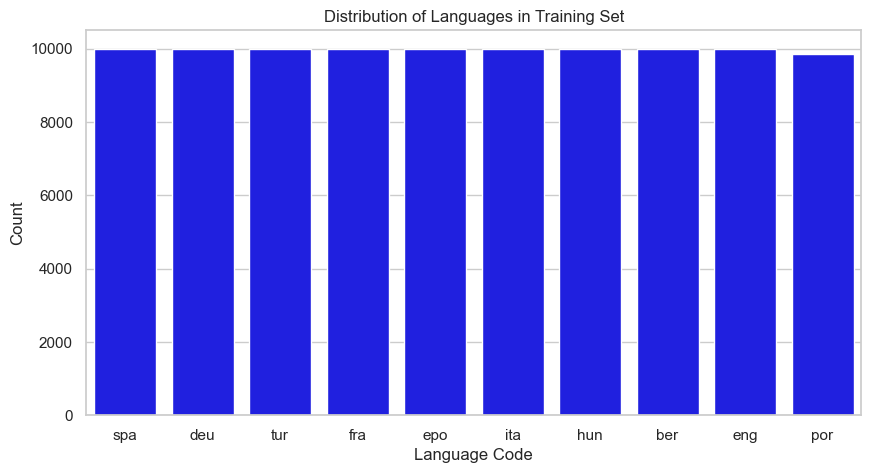

In [5]:
# Plot Language Distribution
plt.figure(figsize=(10, 5))
sns.countplot(x='lang', data=train_df, order=train_df['lang'].value_counts().index, color='blue')
plt.title("Distribution of Languages in Training Set")
plt.xlabel("Language Code")
plt.ylabel("Count")
plt.show()

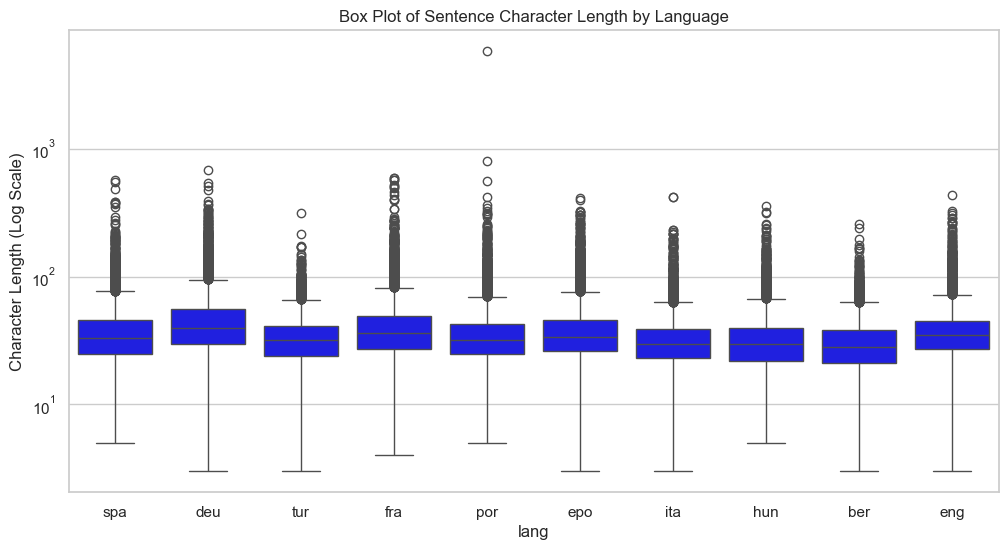

In [6]:
# Box plot for sentence length (characters) per language
plt.figure(figsize=(12, 6))
sns.boxplot(x='lang', y='char_length', data=train_df, color="blue")
plt.title("Box Plot of Sentence Character Length by Language")
plt.yscale('log') # Log scale for better visibility of distributions
plt.ylabel("Character Length (Log Scale)")
plt.show()

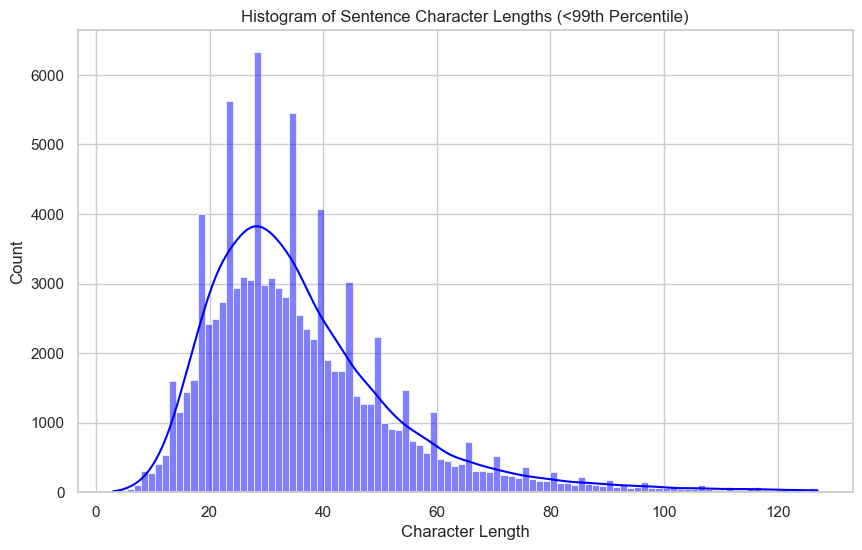

In [7]:
# Histogram of character lengths across the dataset
plt.figure(figsize=(10, 6))
# get subset of data for better visualization
subset_df = train_df[train_df['char_length'] <= np.percentile(train_df['char_length'], 99)]
sns.histplot(subset_df['char_length'], bins=100, kde=True, color='blue')
plt.title("Histogram of Sentence Character Lengths (<99th Percentile)")
plt.xlabel("Character Length")
plt.show()

## 5. Character N-Gram Fingerprinting

Analyzing N-grams (one or more characters) allows us to see how distinct each language is at the character level. This informs the potential accuracy of a character-based RNN. In this case we'll use Bi-grams, as their usage patterns more strongly distinguish languages than single characters (eg, "th" in English).

/var/folders/fk/rq_1swks4wx8ftwh5hbfrpz00000gn/T/ipykernel_98108/1329081961.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(chars), y=list(counts), ax=axes[i], palette='Blues_r')
/var/folders/fk/rq_1swks4wx8ftwh5hbfrpz00000gn/T/ipykernel_98108/1329081961.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(chars), y=list(counts), ax=axes[i], palette='Blues_r')
/var/folders/fk/rq_1swks4wx8ftwh5hbfrpz00000gn/T/ipykernel_98108/1329081961.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(chars), y=list(counts), ax=ax

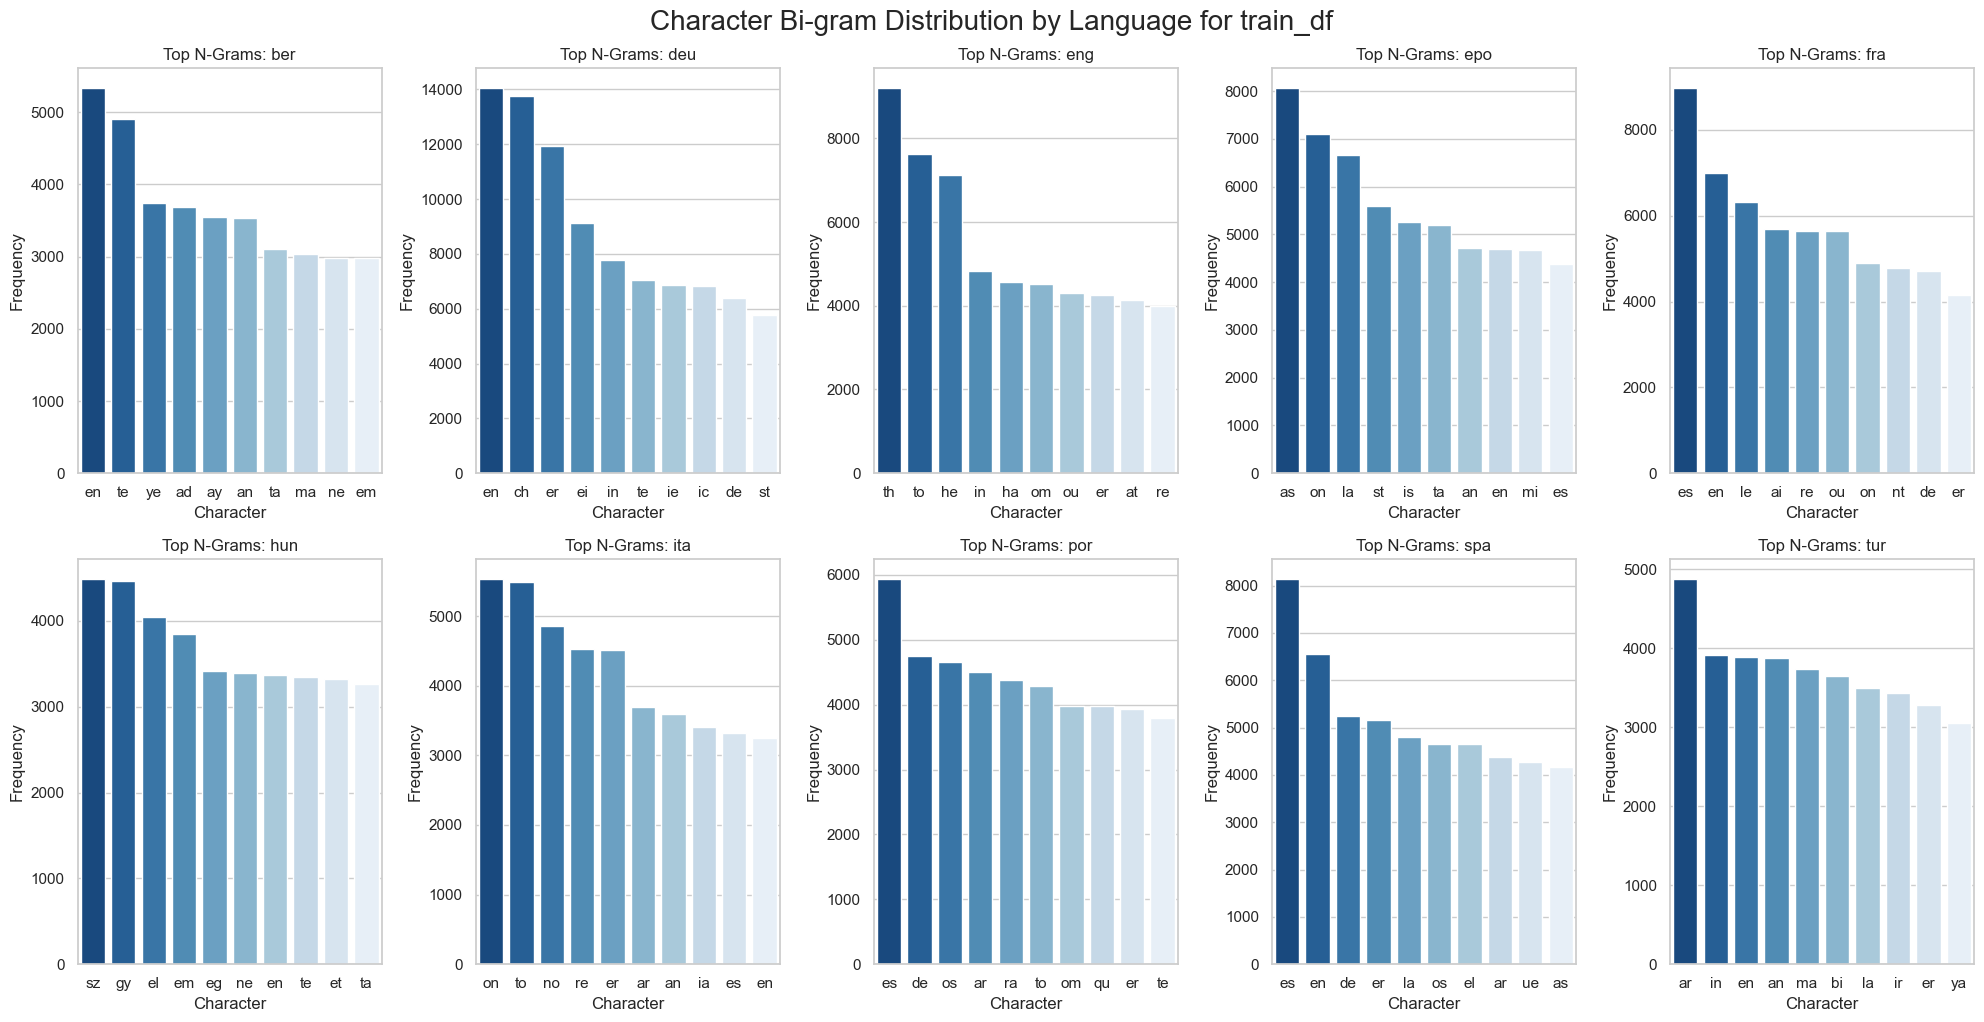

/var/folders/fk/rq_1swks4wx8ftwh5hbfrpz00000gn/T/ipykernel_98108/1329081961.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(chars), y=list(counts), ax=axes[i], palette='Greens_r')
/var/folders/fk/rq_1swks4wx8ftwh5hbfrpz00000gn/T/ipykernel_98108/1329081961.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(chars), y=list(counts), ax=axes[i], palette='Greens_r')
/var/folders/fk/rq_1swks4wx8ftwh5hbfrpz00000gn/T/ipykernel_98108/1329081961.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(chars), y=list(counts), ax=

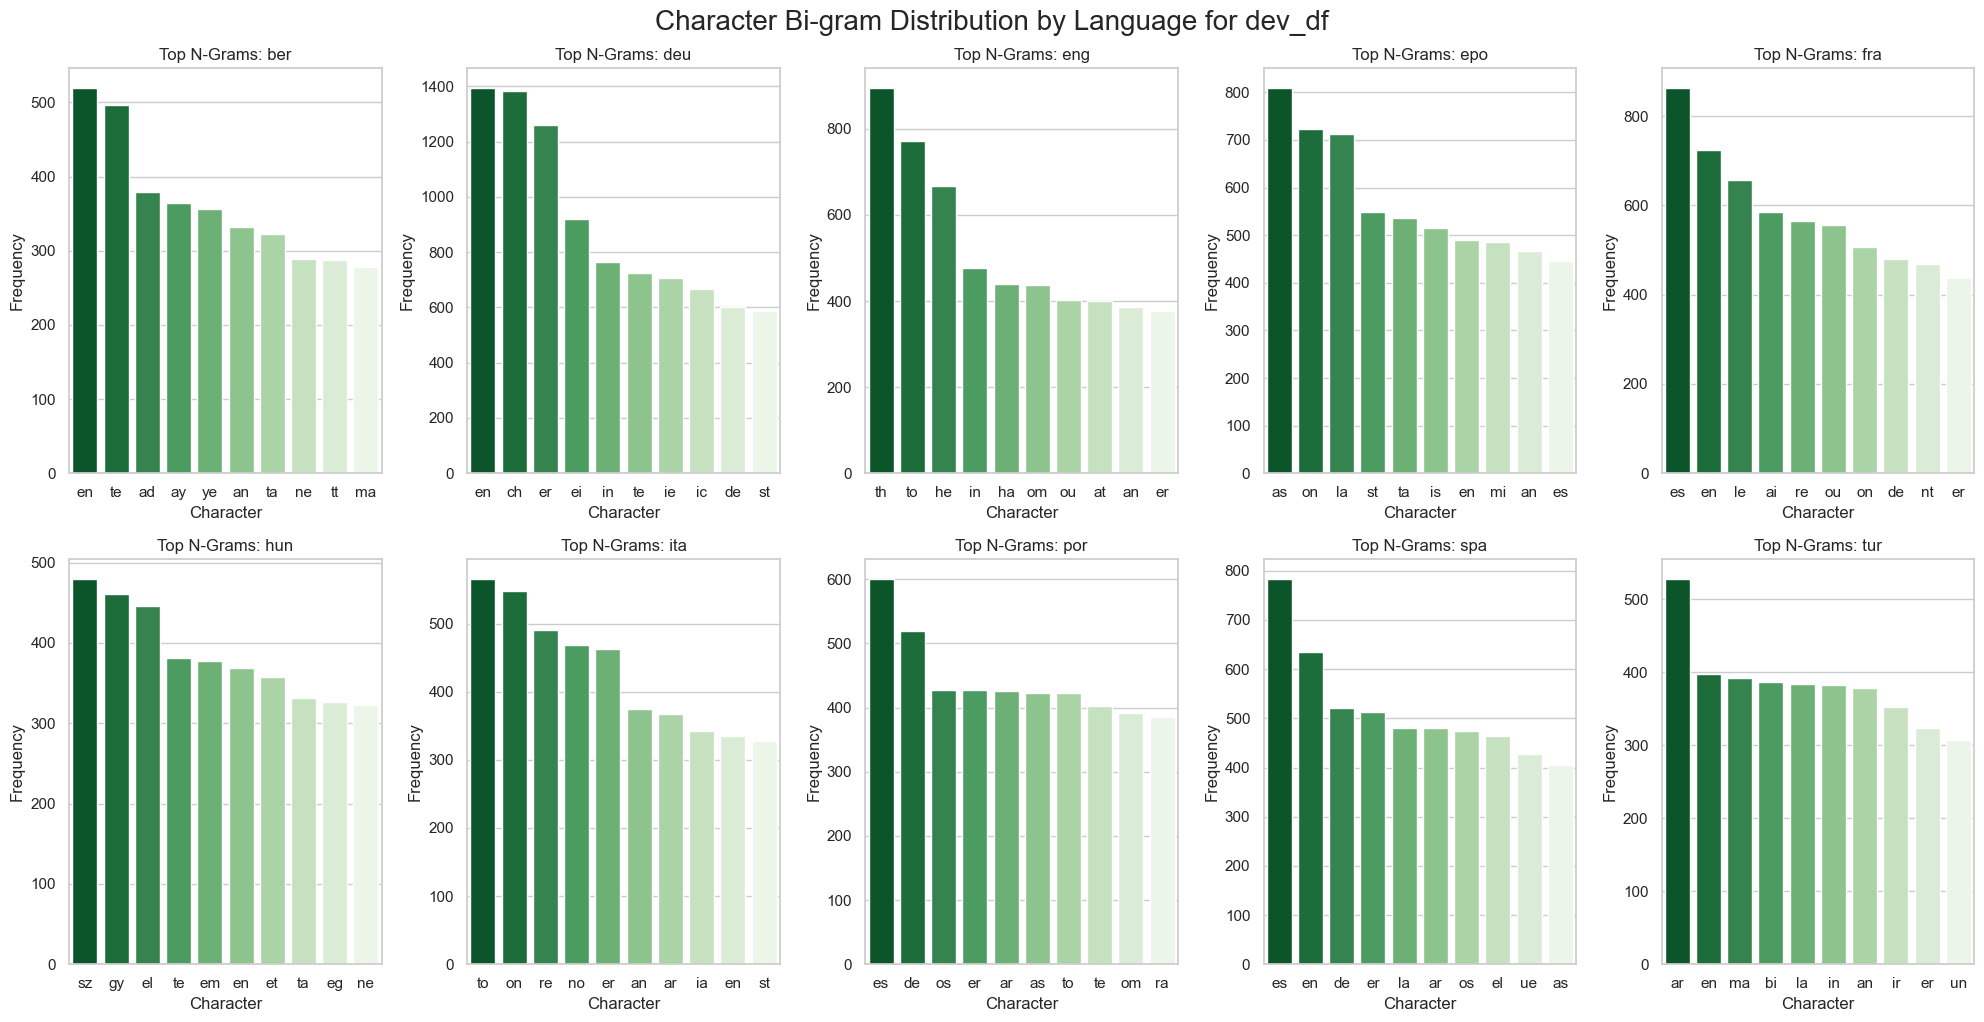

In [8]:
def get_top_ngrams(texts, n=1, top_k=10):
    vec = CountVectorizer(analyzer='char', ngram_range=(n, n)).fit(texts)
    bag_of_words = vec.transform(texts)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:top_k]

languages_train = sorted(train_df['lang'].unique())
fig, axes = plt.subplots(2, 5, figsize=(20, 10), sharey=False)
axes = axes.flatten()

for i, lang in enumerate(languages_train):
    # strip spaces from text for better character counting
    top_unigrams_train = get_top_ngrams(train_df[train_df['lang'] == lang]['text'].str.replace(" ", ""), n=2, top_k=10)
    chars, counts = zip(*top_unigrams_train)
    sns.barplot(x=list(chars), y=list(counts), ax=axes[i], palette='Blues_r')
    axes[i].set_title(f"Top N-Grams: {lang}")
    axes[i].set_xlabel("Character")
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.suptitle("Character Bi-gram Distribution by Language for train_df", fontsize=20, y=1.02)
plt.show()

# same for dev_df
languages_dev = sorted(dev_df['lang'].unique())
fig, axes = plt.subplots(2, 5, figsize=(20, 10), sharey=False)
axes = axes.flatten()

for i, lang in enumerate(languages_dev):
    # strip spaces from text for better character counting
    top_unigrams_dev = get_top_ngrams(dev_df[dev_df['lang'] == lang]['text'].str.replace(" ", ""), n=2, top_k=10)
    chars, counts = zip(*top_unigrams_dev)
    sns.barplot(x=list(chars), y=list(counts), ax=axes[i], palette='Greens_r')
    axes[i].set_title(f"Top N-Grams: {lang}")
    axes[i].set_xlabel("Character")
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.suptitle("Character Bi-gram Distribution by Language for dev_df", fontsize=20, y=1.02)
plt.show()

## 6. Language Similarity Heatmap

We represent each language as its normalized character frequency vector and compute the **Cosine Similarity** between them. This identifies linguistic clusters that are most likely to be confused.

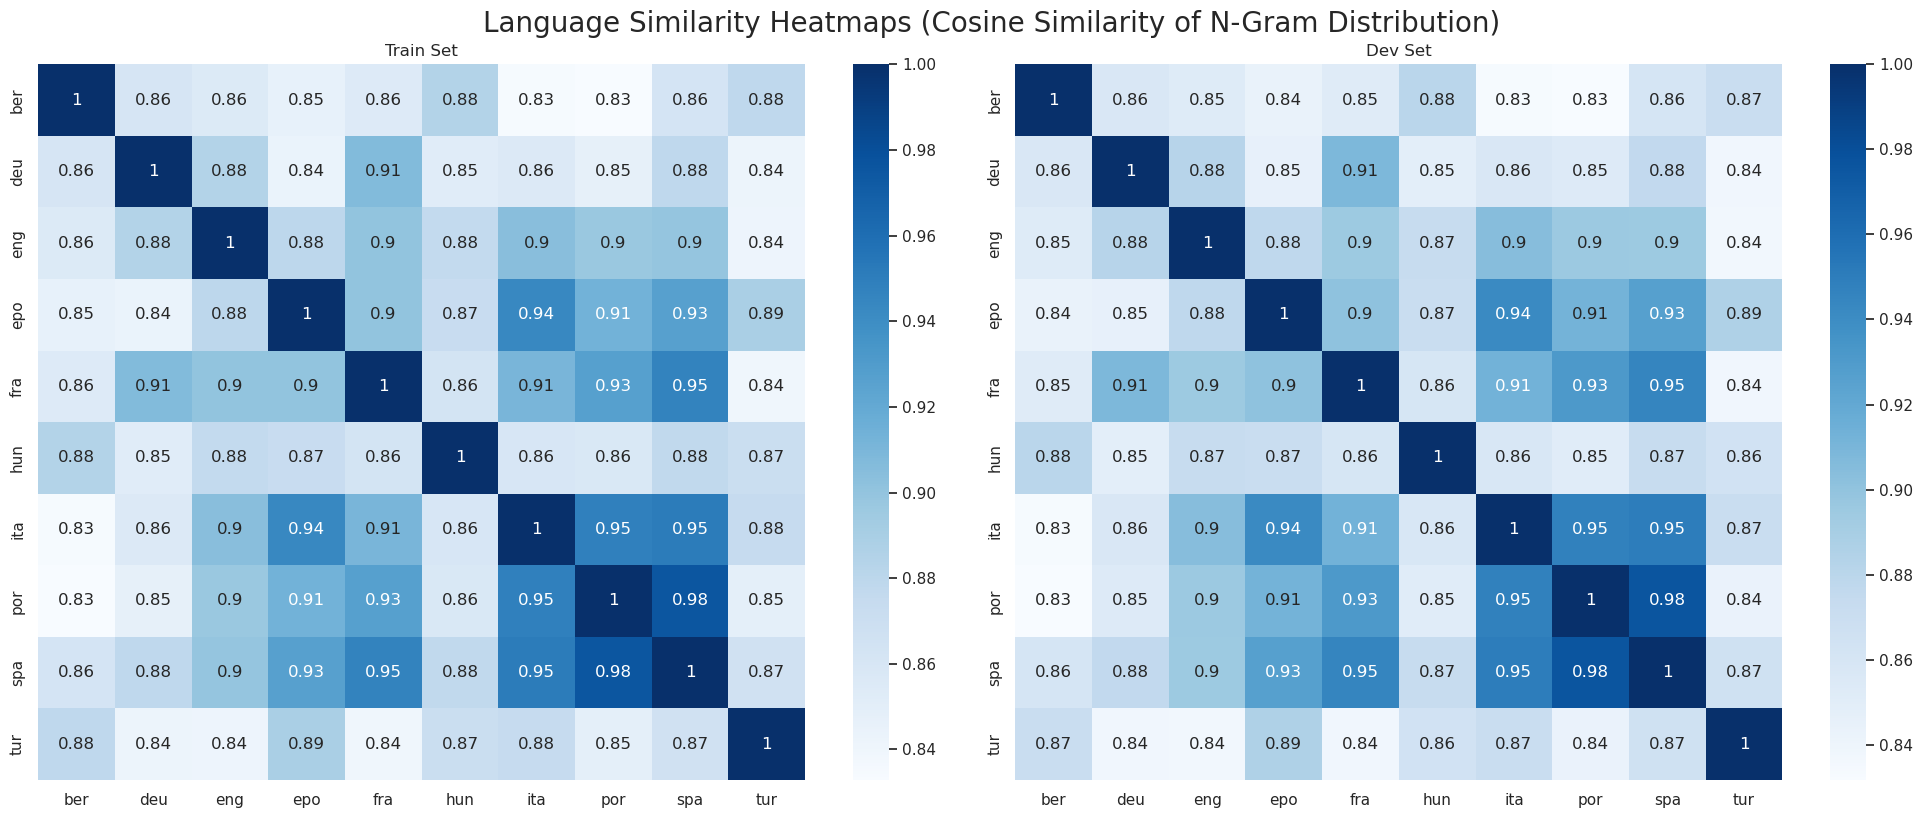

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharey=False)
axes = axes.flatten()

# --- For train_df ---
cv_train = CountVectorizer(analyzer='char', ngram_range=(1, 3)) # include unigrams, bigrams, and trigrams
X_train = cv_train.fit_transform(train_df['text'])
 
languages_train = sorted(train_df['lang'].unique())
lang_vectors_train = []
for lang in languages_train:
    indices = train_df[train_df['lang'] == lang].index
    lang_vec = X_train[indices].sum(axis=0)
    lang_vectors_train.append(np.asarray(lang_vec).flatten())
 
lang_vectors_train = np.array(lang_vectors_train)
sim_matrix_train = cosine_similarity(lang_vectors_train)
 
sns.heatmap(sim_matrix_train, annot=True, ax=axes[0], xticklabels=languages_train, yticklabels=languages_train, cmap='Blues')
axes[0].set_title("Train Set")

# --- For dev_df ---
cv_dev = CountVectorizer(analyzer='char', ngram_range=(1, 3)) # include unigrams, bigrams, and trigrams
X_dev = cv_dev.fit_transform(dev_df['text'])
 
languages_dev = sorted(dev_df['lang'].unique())
lang_vectors_dev = []
for lang in languages_dev:
    indices = dev_df[dev_df['lang'] == lang].index
    lang_vec = X_dev[indices].sum(axis=0)
    lang_vectors_dev.append(np.asarray(lang_vec).flatten())
 
lang_vectors_dev = np.array(lang_vectors_dev)
sim_matrix_dev = cosine_similarity(lang_vectors_dev)
 
sns.heatmap(sim_matrix_dev, annot=True, ax=axes[1], xticklabels=languages_dev, yticklabels=languages_dev, cmap='Blues')
axes[1].set_title("Dev Set")

# add title for entire figure
plt.tight_layout()
plt.suptitle("Language Similarity Heatmaps (Cosine Similarity of N-Gram Distribution)", fontsize=20, y=1.02)
plt.show()

## 7. Dimensionality Reduction (t-SNE)

Sampling 1000 sentences from each language and visualizing their character frequency vectors in 2D space to check for manifold separability.

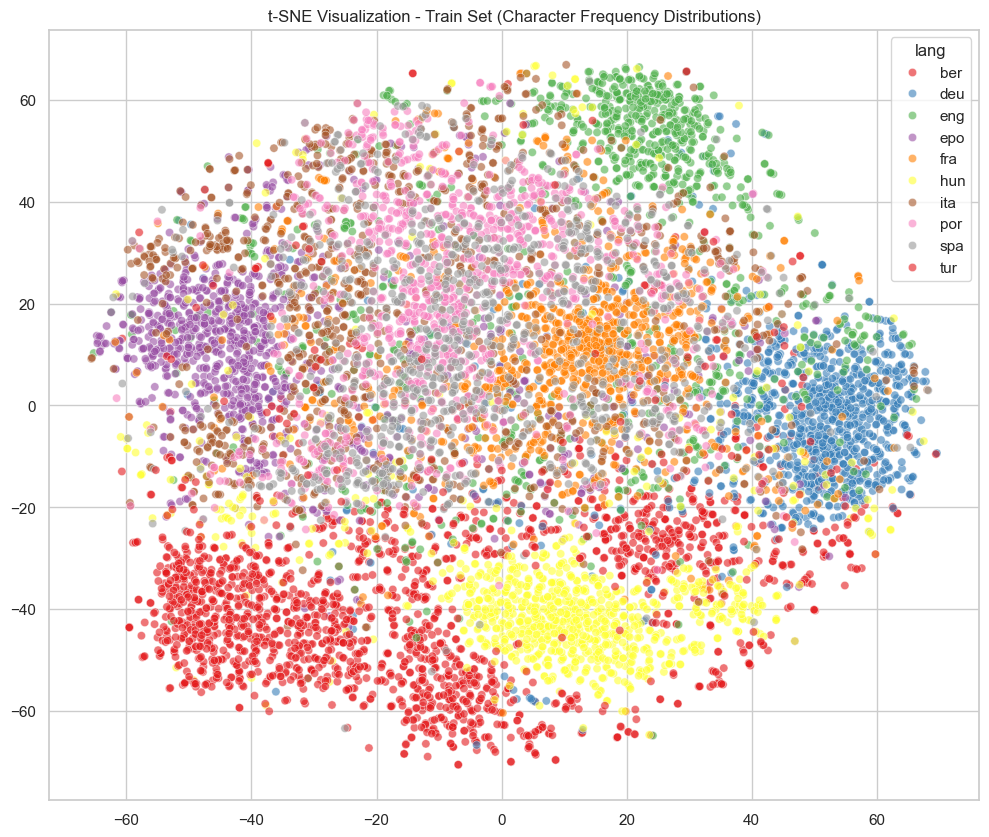

In [10]:
# --- For train_df ---
cv_train = CountVectorizer(analyzer='char')
cv_train.fit(train_df['text'])
 
subset_train = train_df.groupby('lang').sample(n=1000, random_state=42)
X_subset_train = cv_train.transform(subset_train['text'])
X_normalized_train = normalize(X_subset_train, norm='l1', axis=1)
 
tsne_train = TSNE(n_components=2, random_state=42, perplexity=30)
X_embedded_train = tsne_train.fit_transform(X_normalized_train.toarray())
 
plt.figure(figsize=(12, 10))
sns.scatterplot(x=X_embedded_train[:, 0], y=X_embedded_train[:, 1], 
                hue=subset_train['lang'], palette='Set1', alpha=0.6)
plt.title('t-SNE Visualization - Train Set (Character Frequency Distributions)')
plt.show()

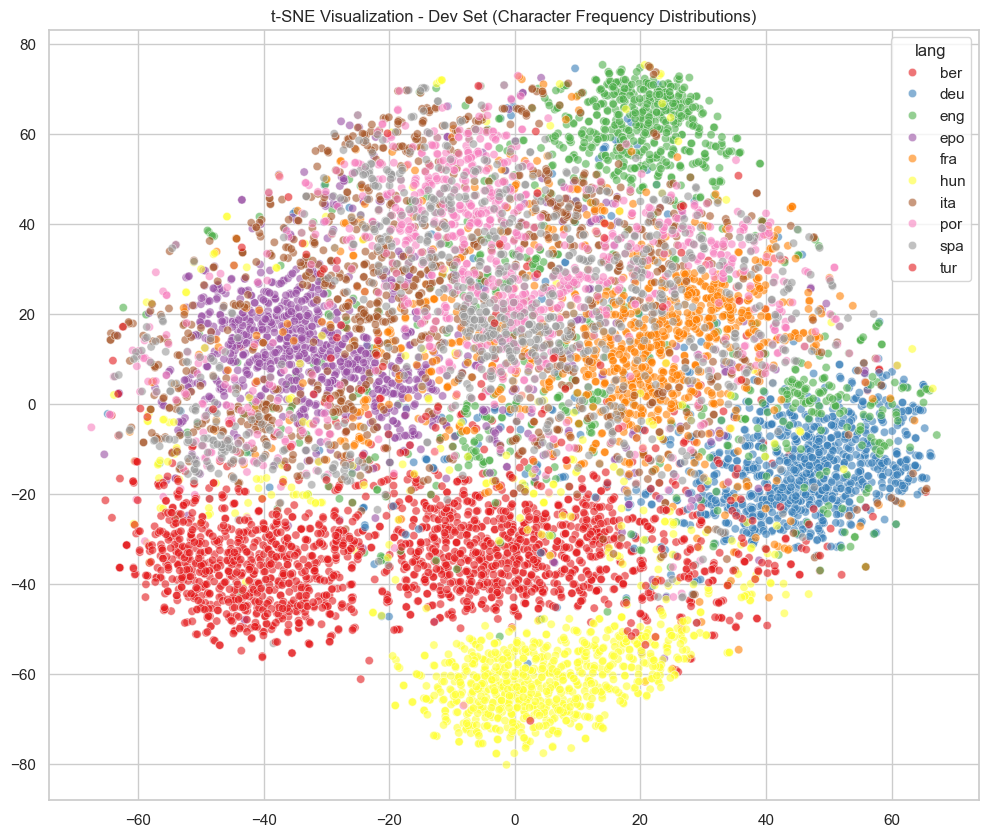

In [11]:
# --- For dev_df ---
cv_dev = CountVectorizer(analyzer='char')
cv_dev.fit(dev_df['text'])
 
subset_dev = dev_df.groupby('lang').sample(n=1000, random_state=42)
X_subset_dev = cv_dev.transform(subset_dev['text'])
X_normalized_dev = normalize(X_subset_dev, norm='l1', axis=1)
 
tsne_dev = TSNE(n_components=2, random_state=42, perplexity=30)
X_embedded_dev = tsne_dev.fit_transform(X_normalized_dev.toarray())
 
plt.figure(figsize=(12, 10))
sns.scatterplot(x=X_embedded_dev[:, 0], y=X_embedded_dev[:, 1], 
                hue=subset_dev['lang'], palette='Set1', alpha=0.6)
plt.title('t-SNE Visualization - Dev Set (Character Frequency Distributions)')
plt.show()

## 8. Lexical Complexity Diagnostics

We calculate the character entropy per language. Higher entropy suggests more complex character usage patterns, which might require a more complex RNN or a larger embedding size.

/var/folders/fk/rq_1swks4wx8ftwh5hbfrpz00000gn/T/ipykernel_98108/2625186589.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=entropy_avg_train.index, y=entropy_avg_train.values, palette='coolwarm')


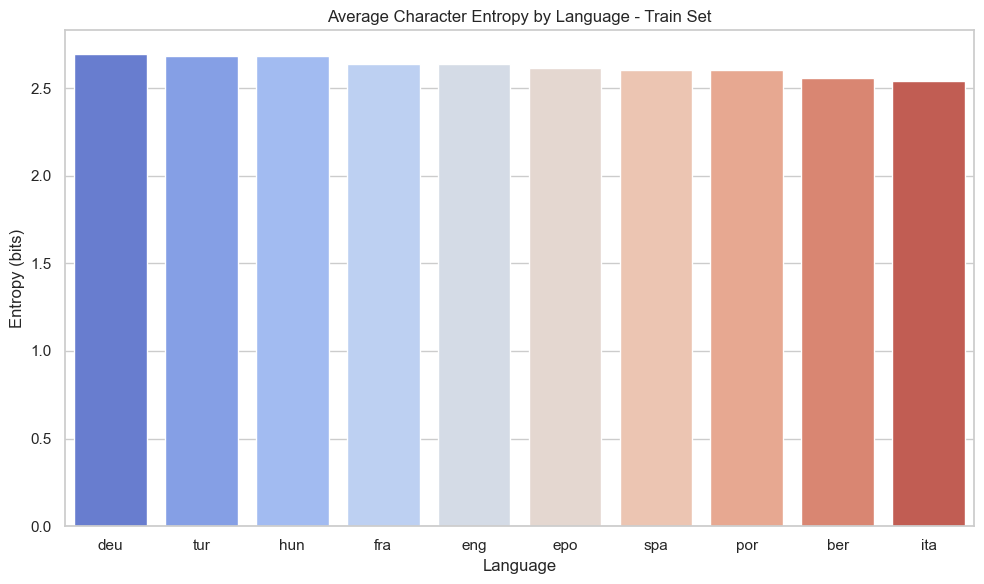

In [12]:
from collections import Counter
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt

def calculate_entropy(text):
    prob = [n_c/len(text) for char, n_c in Counter(text).items()]
    return stats.entropy(prob)

# --- For train_df ---
train_df['entropy'] = train_df['text'].apply(calculate_entropy)
entropy_avg_train = train_df.groupby('lang')['entropy'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=entropy_avg_train.index, y=entropy_avg_train.values, palette='coolwarm')
plt.title("Average Character Entropy by Language - Train Set")
plt.ylabel("Entropy (bits)")
plt.xlabel("Language")
plt.tight_layout()
plt.show()

/var/folders/fk/rq_1swks4wx8ftwh5hbfrpz00000gn/T/ipykernel_98108/3035932593.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=entropy_avg_dev.index, y=entropy_avg_dev.values, palette='coolwarm')


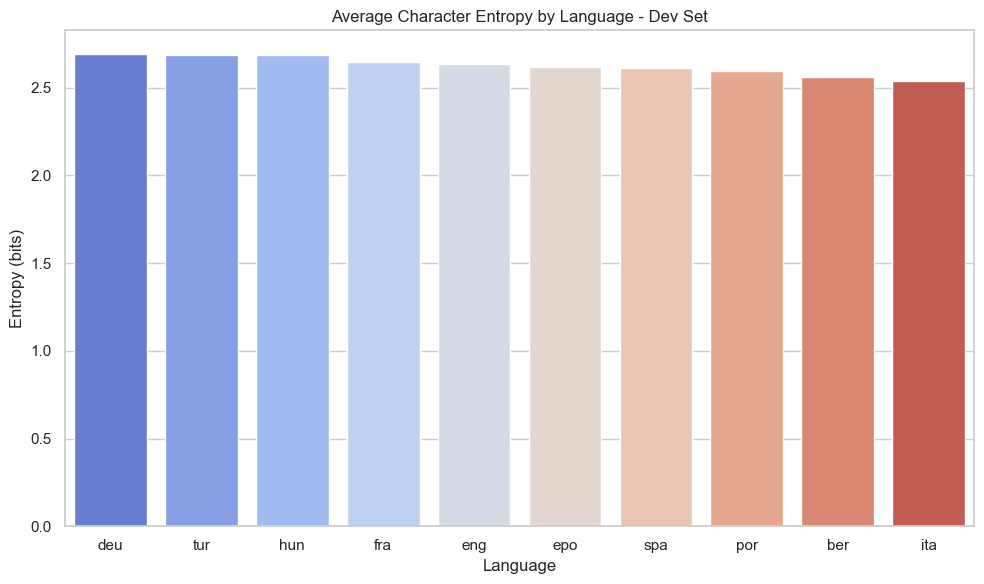

In [13]:
# --- For dev_df ---
dev_df['entropy'] = dev_df['text'].apply(calculate_entropy)
entropy_avg_dev = dev_df.groupby('lang')['entropy'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=entropy_avg_dev.index, y=entropy_avg_dev.values, palette='coolwarm')
plt.title("Average Character Entropy by Language - Dev Set")
plt.ylabel("Entropy (bits)")
plt.xlabel("Language")
plt.tight_layout()
plt.show()

## 9. Unique Characters

Find characters that are exclusive to a single language — these are the most informative features for detection

Unique characters for ber: {'ḅ', 'Ɣ', 'ⴻ', 'Ṣ', 'Ṛ', 'ⵃ', 'č', 'ⴽ', 'ⵓ', 'ⴹ', 'ⵡ', 'ⵎ', 'ṭ', 'Č', 'ṣ', 'ḥ', 'γ', 'Ḥ', 'ⵍ', 'ɛ', 'ṃ', 'ń', 'ⵔ', 'ⵏ', 'Ǧ', 'ⴰ', 'ⵖ', 'ⵥ', 'ⵞ', 'ẓ', 'Ṭ', '‑', 'ⵢ', 'ⴷ', 'Ḍ', 'ⵟ', 'ɣ', 'ǧ', 'ḷ', 'ʷ', 'ε', 'ḍ', 'Ɛ', 'ⵜ', 'Ẓ', 'Γ', 'ⵣ', 'ⵉ'}
Unique characters for deu: {'─', '‚', 'Ō', 'ǐ', 'š', 'Ä', 'ß', 'ā', 'ć'}
Unique characters for eng: {'º', '³', '¥', '¹', 'π'}
Unique characters for epo: {'Ĝ', 'ĵ', 'ŭ', 'ŝ', 'ĥ', 'Ĉ', 'ĉ', 'Ĵ', 'Ŝ'}
Unique characters for fra: {'ï', '\u2009', 'ẽ', 'Î', '₫', 'œ', 'Ê'}
Unique characters for hun: {'Ł', 'ė', 'Ő', 'ő'}
Unique characters for ita: {'あ', 'а', 'ò', '→'}
Unique characters for por: {'\n', '\u200e', 'õ', '\t'}
Unique characters for spa: {'¡', 'С', '>', '¿'}
Unique characters for tur: {'ş', 'İ', 'Ş', 'ı'}


/var/folders/fk/rq_1swks4wx8ftwh5hbfrpz00000gn/T/ipykernel_98108/3927395917.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(chars), y=list(counts), ax=axes[i], palette='Blues_r')
/var/folders/fk/rq_1swks4wx8ftwh5hbfrpz00000gn/T/ipykernel_98108/3927395917.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(chars), y=list(counts), ax=axes[i], palette='Blues_r')
/var/folders/fk/rq_1swks4wx8ftwh5hbfrpz00000gn/T/ipykernel_98108/3927395917.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(chars), y=list(counts), ax=ax

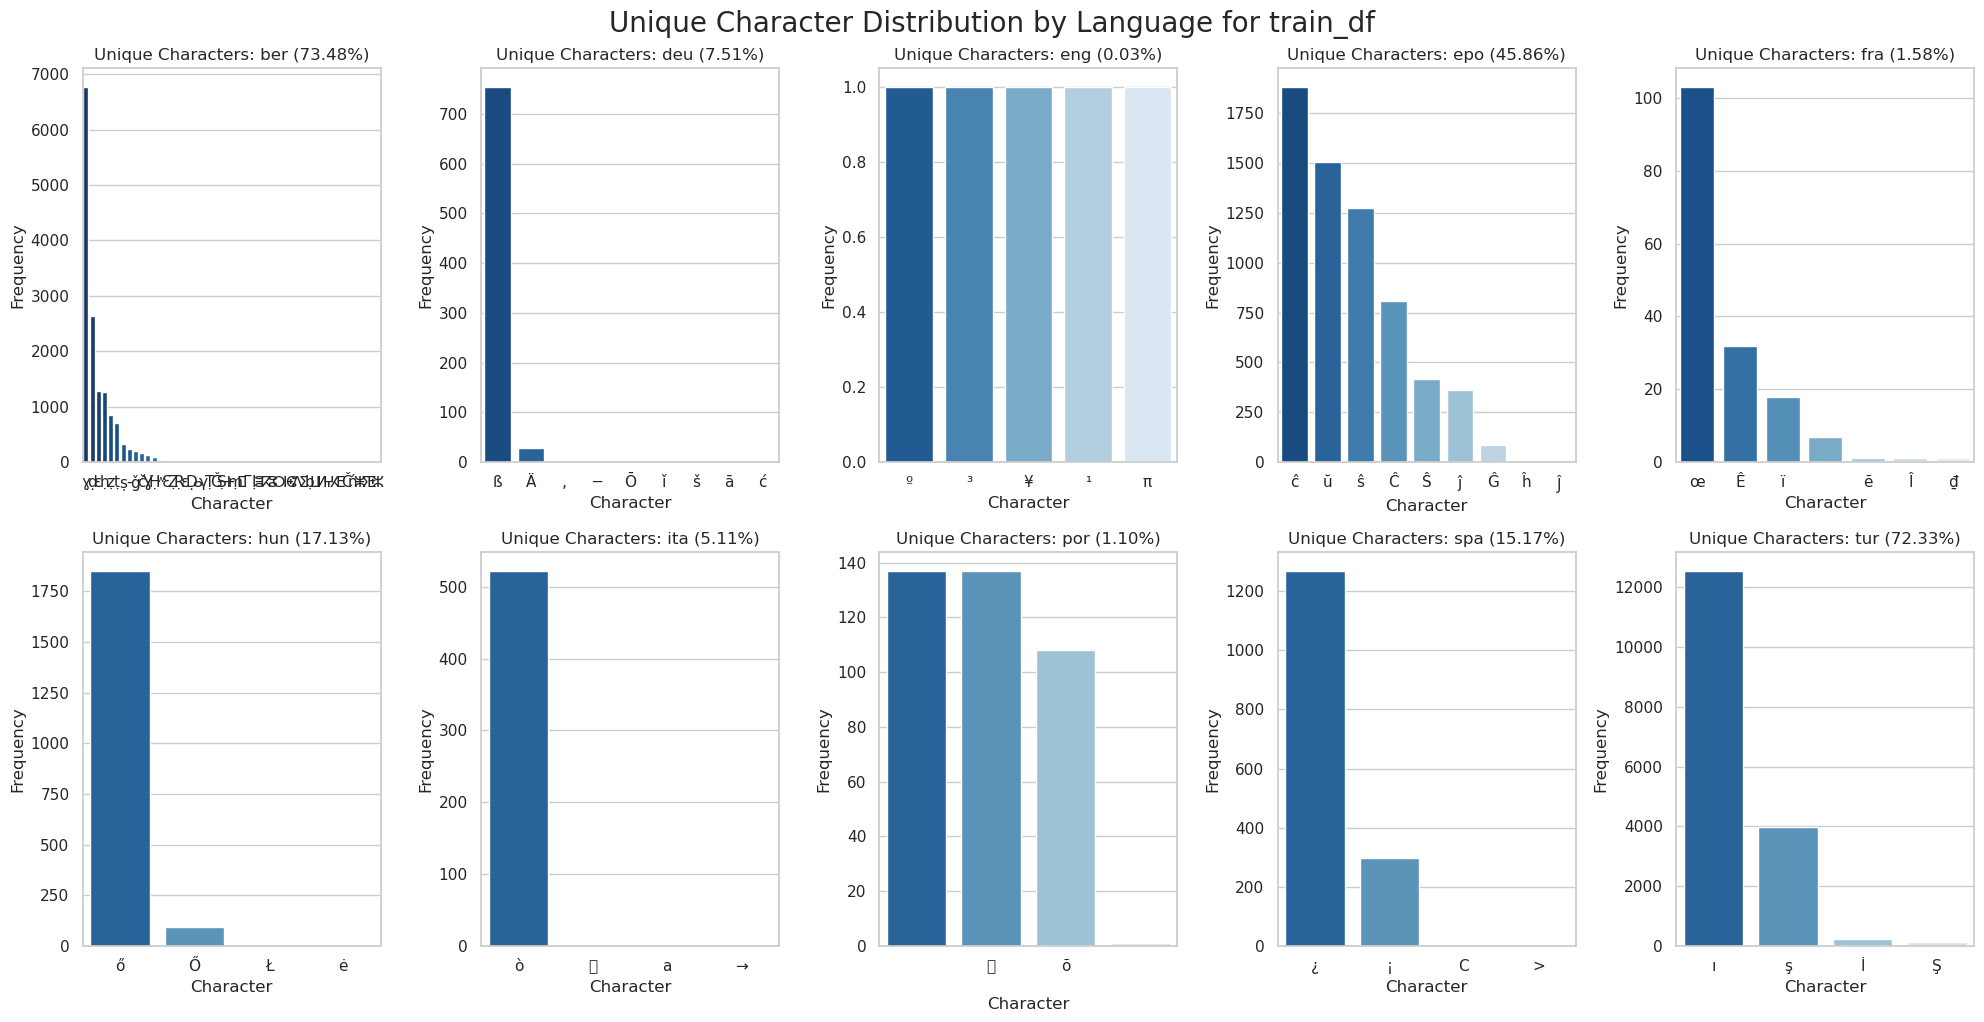

In [14]:
# find characters that are unique to each language in the train set
unique_chars_train = {}
for lang in languages_train:
    chars = set(''.join(train_df[train_df['lang'] == lang]['text'].str.replace(" ", "")))
    other_chars = set(''.join(train_df[train_df['lang'] != lang]['text'].str.replace(" ", "")))
    unique_chars_train[lang] = chars - other_chars
    # exclude spaces from the unique character sets
    unique_chars_train[lang] = unique_chars_train[lang] - {' '}
    print(f"Unique characters for {lang}: {unique_chars_train[lang]}")

# test if the unique characters are actually unique by checking other languages in dev_df
for lang in languages_train:
    unique_chars = unique_chars_train[lang]
    for other_lang in languages_dev:
        if other_lang != lang:
            other_chars = set(''.join(dev_df[dev_df['lang'] == other_lang]['text'].str.replace(" ", "")))
            overlap = unique_chars.intersection(other_chars)
            if overlap:
                print(f"Warning: Unique characters for {lang} are found in {other_lang} in dev set: {overlap}")

# suppress errors for missing font glyphs (e.g., for non-Latin characters)
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")
warnings.filterwarnings("ignore", category=UserWarning, module="seaborn")
# if a font glyph is missing, replace the characters with the escaped unicode code point (e.g., \uXXXX) instead of showing a warning
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family'] = 'DejaVu Sans'  # Use a font that has wide Unicode support

# visualize the frequency of the unique characters for each language in the train set
fig, axes = plt.subplots(2, 5, figsize=(20, 10), sharey=False)
axes = axes.flatten()  
lang_unique_percentages = {} 
for i, lang in enumerate(languages_train):
    unique_chars = unique_chars_train[lang]
    char_counts = Counter(''.join(train_df[train_df['lang'] == lang]['text'].str.replace(" ", "")))
    unique_char_counts = {char: char_counts[char] for char in unique_chars}
    sorted_chars_counts = sorted(unique_char_counts.items(), key=lambda x: x[1], reverse=True)
    chars, counts = zip(*sorted_chars_counts)    
    sns.barplot(x=list(chars), y=list(counts), ax=axes[i], palette='Blues_r')
    # calculate the percentage of texts in the language that contain at least one of the unique characters
    texts_with_unique_char = train_df[train_df['lang'] == lang]['text'].apply(lambda x: any(char in x for char in unique_chars)).sum()
    total_texts = len(train_df[train_df['lang'] == lang])
    percentage = (texts_with_unique_char / total_texts) * 100
    lang_unique_percentages[lang] = percentage
    axes[i].set_title(f"Unique Characters: {lang} ({percentage:.2f}%)")
    axes[i].set_xlabel("Character")
    axes[i].set_ylabel("Frequency")
plt.tight_layout()
plt.suptitle("Unique Character Distribution by Language for train_df", fontsize=20, y=1.02)
plt.show()

## 10. Unicode Identification

Identify which Unicode blocks (Latin, Cyrillic, Arabic, etc.) each language uses — this is one of the strongest discriminating signals for a character-level RNN

/var/folders/fk/rq_1swks4wx8ftwh5hbfrpz00000gn/T/ipykernel_98108/3299411096.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(block_names), y=list(counts), ax=axes[i], palette='Blues_r')
/var/folders/fk/rq_1swks4wx8ftwh5hbfrpz00000gn/T/ipykernel_98108/3299411096.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(block_names), y=list(counts), ax=axes[i], palette='Blues_r')
/var/folders/fk/rq_1swks4wx8ftwh5hbfrpz00000gn/T/ipykernel_98108/3299411096.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(block_names), y=l

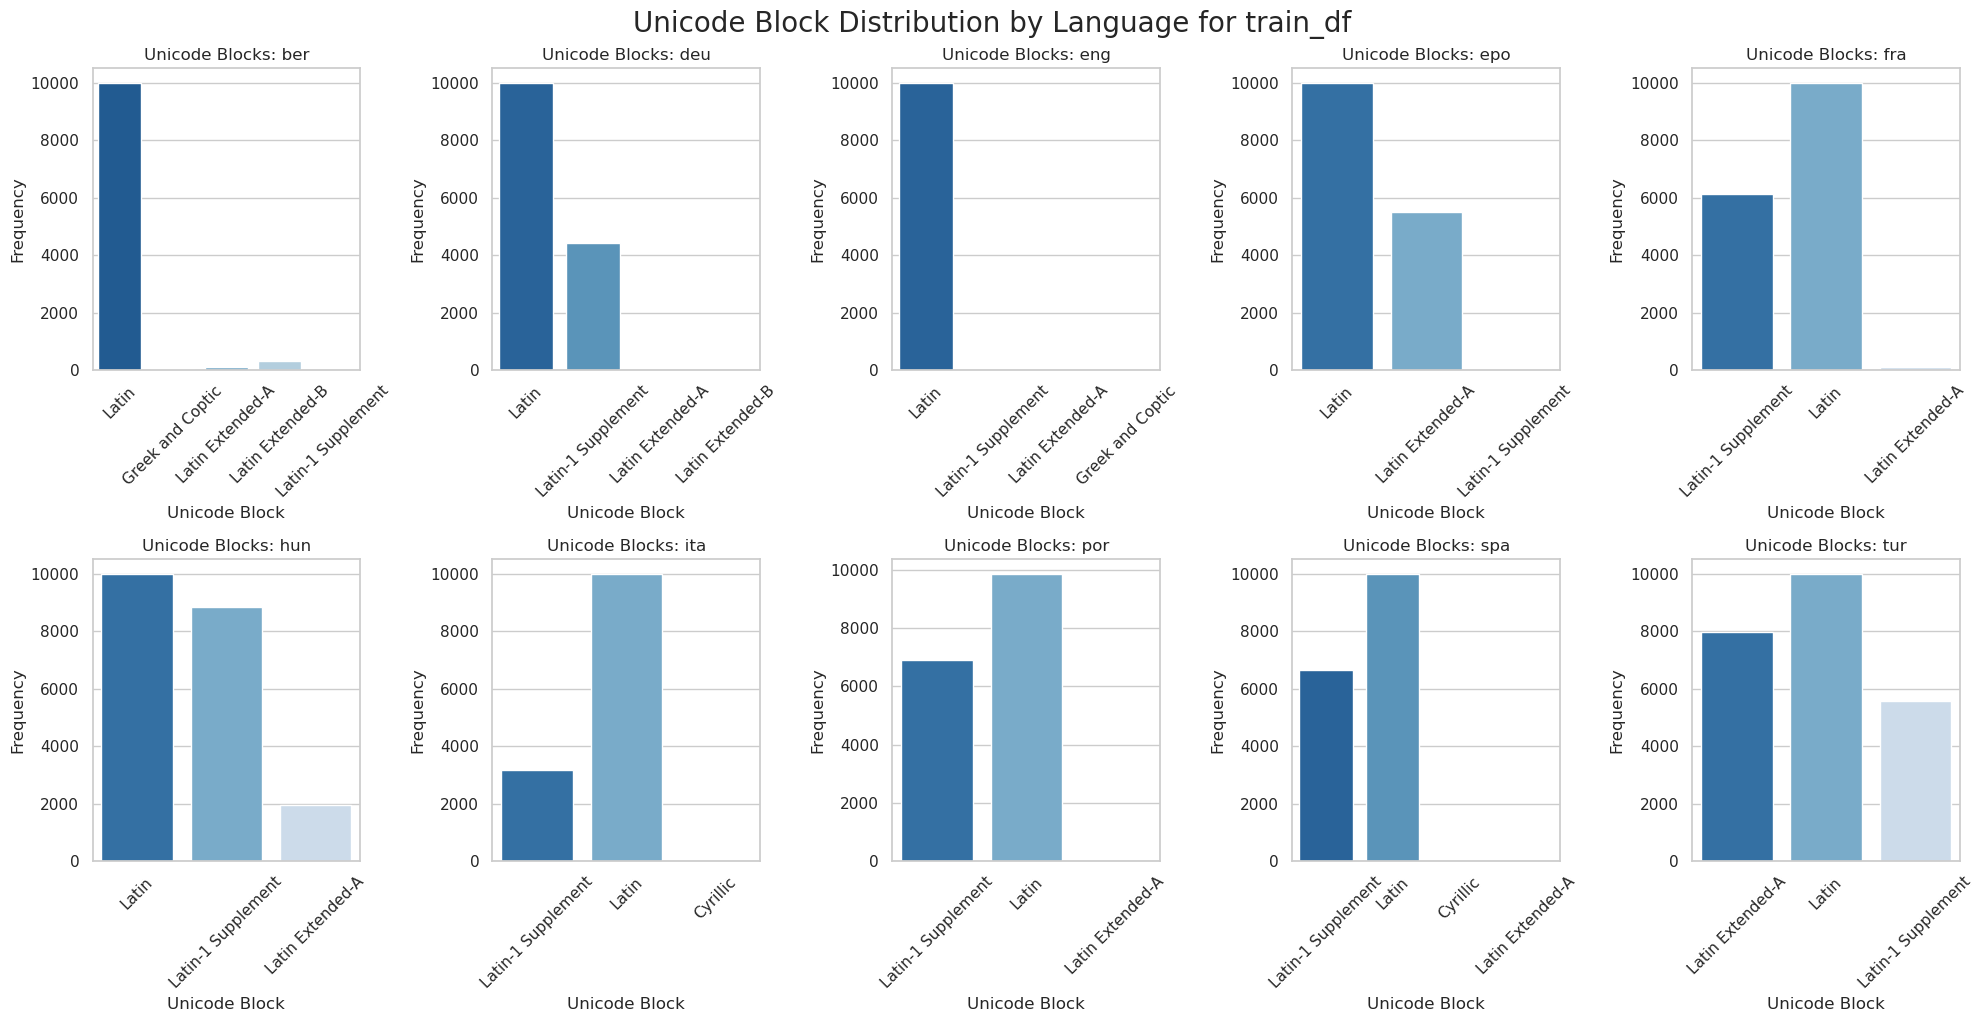

In [15]:
# Identify which Unicode blocks the train_df languages belong to
unicode_blocks = {
    'Latin': (0x0000, 0x007F),
    'Latin-1 Supplement': (0x0080, 0x00FF),
    'Latin Extended-A': (0x0100, 0x017F),
    'Latin Extended-B': (0x0180, 0x024F),
    'Cyrillic': (0x0400, 0x04FF),
    'Cyrillic Supplement': (0x0500, 0x052F),
    'Greek and Coptic': (0x0370, 0x03FF),
    'Arabic': (0x0600, 0x06FF),
    'Hebrew': (0x0590, 0x05FF),
    'Devanagari': (0x0900, 0x097F)
}
def identify_unicode_blocks(text):
    blocks = set()
    for char in text:
        code_point = ord(char)
        for block_name, (start, end) in unicode_blocks.items():
            if start <= code_point <= end:
                blocks.add(block_name)
                break
    return blocks

train_df['unicode_blocks'] = train_df['text'].apply(identify_unicode_blocks)
#dev_df['unicode_blocks'] = dev_df['text'].apply(identify_unicode_blocks)

# now visualize the distribution of unicode blocks for each language in the train set
fig, axes = plt.subplots(2, 5, figsize=(20, 10), sharey=False)
axes = axes.flatten()
for i, lang in enumerate(languages_train):
    blocks = Counter()
    for block_set in train_df[train_df['lang'] == lang]['unicode_blocks']:
        blocks.update(block_set)
    block_names, counts = zip(*blocks.items())
    sns.barplot(x=list(block_names), y=list(counts), ax=axes[i], palette='Blues_r')
    axes[i].set_title(f"Unicode Blocks: {lang}")
    axes[i].set_xlabel("Unicode Block")
    axes[i].set_ylabel("Frequency")
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.suptitle("Unicode Block Distribution by Language for train_df", fontsize=20, y=1.02)
plt.show()

## 11. Logistic Regression

We run a baseline logistic regression and examine the confusion matrix to see how separable the languages are.

In [16]:
# perform a simple logistic regression analysis to see if we can predict language based on character distribution features

# extract features from train_df using CountVectorizer with character n-grams
cv = CountVectorizer(analyzer='char', ngram_range=(1, 3)) # include unigrams, bigrams, and trigrams
X_train = cv.fit_transform(train_df['text'])
y_train = train_df['lang']

# fit a logistic regression model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

# make predictions on the dev set
X_test = cv.transform(dev_df['text'])
y_test = dev_df['lang']
y_pred = lr.predict(X_test)

# evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9929
Classification Report:
              precision    recall  f1-score   support

         ber       0.99      1.00      1.00      1000
         deu       1.00      1.00      1.00      1000
         eng       0.99      0.99      0.99      1000
         epo       1.00      1.00      1.00      1000
         fra       1.00      0.99      0.99      1000
         hun       0.99      1.00      1.00      1000
         ita       0.99      0.99      0.99      1000
         por       0.99      0.98      0.99      1000
         spa       0.98      0.99      0.98      1000
         tur       1.00      1.00      1.00      1000

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



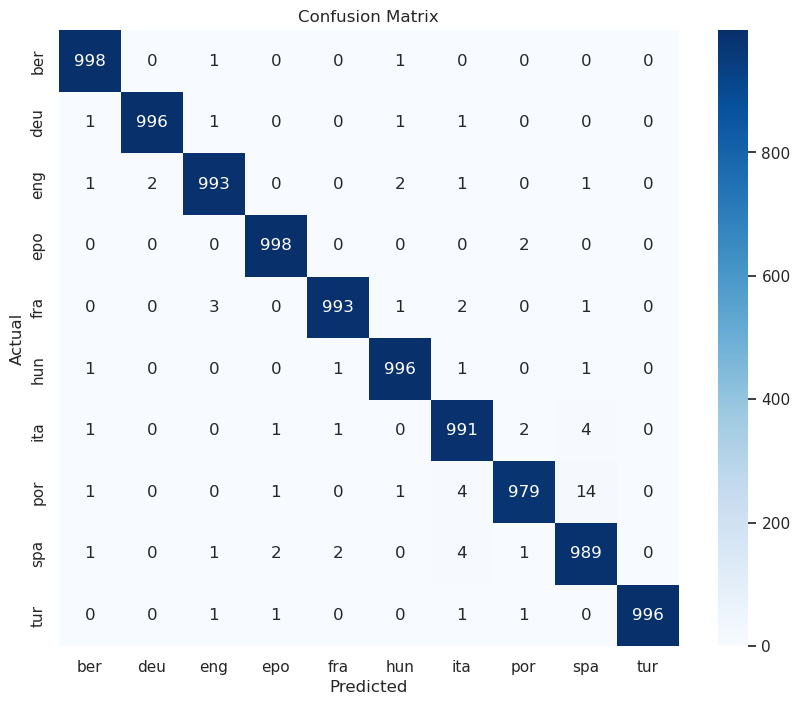

In [17]:
# visualize the confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred, labels=lr.classes_)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=lr.classes_, yticklabels=lr.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [18]:
# Calculate 95th percentile for both datasets
train_95th = np.percentile(train_df['char_length'], 95)
dev_95th = np.percentile(dev_df['text'].str.len(), 95)

# Get vocabulary sizes
cv_vocab = CountVectorizer(analyzer='char')
cv_vocab.fit(train_df['text'])
vocab_size = len(cv_vocab.vocabulary_)

# Calculate specific similarity values from train set heatmap
languages = train_df['lang'].unique()
cv_summary = CountVectorizer(analyzer='char')
X_summary = cv_summary.fit_transform(train_df['text'])
lang_vecs = []
for lang in languages:
    idx = train_df[train_df['lang'] == lang].index
    vec = X_summary[idx].sum(axis=0)
    lang_vecs.append(np.asarray(vec).flatten())
lang_vecs = np.array(lang_vecs)
sim_matrix_summary = cosine_similarity(lang_vecs)

# Get indices for spa, por, ita
lang_idx = {lang: i for i, lang in enumerate(languages)}
spa_por_sim = sim_matrix_summary[lang_idx['spa']][lang_idx['por']]
spa_ita_sim = sim_matrix_summary[lang_idx['spa']][lang_idx['ita']]
por_ita_sim = sim_matrix_summary[lang_idx['por']][lang_idx['ita']]

# get the % of texts containing unique characters per languages
unique_char_percentages = {f"{lang}: {lang_unique_percentages[lang]:.2f}%" for lang in languages}

# get count of texts misclassified between spanish and portuguese
cm_df = pd.DataFrame(cm, index=lr.classes_, columns=lr.classes_)
misclassified_spa_as_por = cm_df.loc['spa', 'por']
misclassified_por_as_spa = cm_df.loc['por', 'spa']
misclassified_por_or_spa = misclassified_spa_as_por + misclassified_por_as_spa

print(f"""
Summary

- Dataset Sizes: Train: {len(train_df):,} sentences, Dev: {len(dev_df):,} sentences
- Sequence Length: 95th percentile is ~{train_95th:.0f} characters (train) and ~{dev_95th:.0f} characters (dev)
- Vocabulary Size: Character vocabulary contains {vocab_size} unique characters across all languages
- Language Similarities (N-Gram Distribution):
  - Spanish-Portuguese: {spa_por_sim:.3f}
  - Spanish-Italian: {spa_ita_sim:.3f}
  - Portuguese-Italian: {por_ita_sim:.3f}
- Confusions: Spanish (spa), Portuguese (por), and Italian (ita) show the highest similarity 
    (~{max(spa_por_sim, spa_ita_sim, por_ita_sim):.2f}), suggesting a need for deeper context or 
    higher sequence lengths to distinguish nuances
- Entropy Range: Character entropy varies from {entropy_avg_train.min():.2f} to {entropy_avg_train.max():.2f} bits across languages
- Texts with language-specific characters: {unique_char_percentages}
- All languages predominantly use characters from the Latin Unicode blocks.
- Logistic Regression Accuracy: {accuracy:.4f} on dev set, with the most errors ({misclassified_por_or_spa}) between Spanish and Portuguese
""")


Summary

- Dataset Sizes: Train: 99,863 sentences, Dev: 10,000 sentences
- Sequence Length: 95th percentile is ~74 characters (train) and ~75 characters (dev)
- Vocabulary Size: Character vocabulary contains 178 unique characters across all languages
- Language Similarities (N-Gram Distribution):
  - Spanish-Portuguese: 0.989
  - Spanish-Italian: 0.973
  - Portuguese-Italian: 0.972
- Confusions: Spanish (spa), Portuguese (por), and Italian (ita) show the highest similarity 
    (~0.99), suggesting a need for deeper context or 
    higher sequence lengths to distinguish nuances
- Entropy Range: Character entropy varies from 2.54 to 2.69 bits across languages
- Texts with language-specific characters: {'eng: 0.03%', 'deu: 7.51%', 'ber: 73.48%', 'por: 1.10%', 'epo: 45.86%', 'hun: 17.13%', 'spa: 15.17%', 'tur: 72.33%', 'fra: 1.58%', 'ita: 5.11%'}
- All languages predominantly use characters from the Latin Unicode blocks.
- Logistic Regression Accuracy: 0.9929 on dev set, with the most err